# 🚗 Lane Detection

## Overview
This notebook contains a computer vision exercise completed during the AI Bootcamp. The project focuses on detecting road lane markings from video frames using classical image processing techniques.

## Objective
The objective of this exercise is to build a lane detection pipeline by applying edge detection, region masking, and Hough Transform to identify road lanes and estimate vehicle position.

## Skills Practiced

- Image Processing
- Edge Detection
- Gaussian Blur
- Region of Interest (ROI)
- Canny Edge Detection
- Hough Line Transform

---
**Tools:** Python, OpenCV, NumPy, Matplotlib

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6,6)

def imshow(img, title="", cmap=None):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def psnr(ref, den):
    mse = np.mean((ref.astype(np.float32) - den.astype(np.float32))**2)
    if mse == 0:
        return 99.0
    return 20 * np.log10(255.0 / np.sqrt(mse))

def to_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

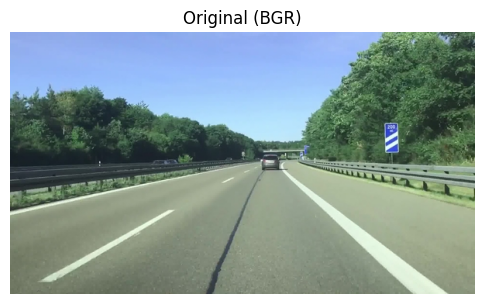

In [2]:
IMG_PATH = "road.jpg"
img_bgr = cv2.imread(IMG_PATH, cv2.IMREAD_COLOR)
assert img_bgr is not None, "تصویر پیدا نشد. مطمئن شوید road.jpg کنار نوت‌بوک هست."
img_gray = to_gray(img_bgr)

imshow(img_bgr, "Original (BGR)")

In [3]:
def add_gaussian_noise(img_u8, sigma=15):
    noise = np.random.normal(0, sigma, img_u8.shape).astype(np.float32)
    noisy = img_u8.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

def add_salt_pepper(img_u8, p=0.02):
    noisy = img_u8.copy()
    rnd = np.random.rand(*img_u8.shape)
    noisy[rnd < p/2] = 0
    noisy[rnd > 1 - p/2] = 255
    return noisy

gauss_noisy = add_gaussian_noise(img_gray, sigma=20)
sp_noisy    = add_salt_pepper(img_gray, p=0.03)


In [4]:
def auto_canny(img_u8, low_ratio=0.66, high_ratio=1.33, blur_ksize=5):
    blurred = cv2.GaussianBlur(img_u8, (blur_ksize, blur_ksize), 0)
    v = np.median(blurred)
    lower = int(max(0, low_ratio * v))
    upper = int(min(255, high_ratio * v))
    edges = cv2.Canny(blurred, lower, upper)
    return edges


In [5]:
def detect_lines_houghp(edges, rho=1, theta=np.pi/180, threshold=50, minLineLength=50, maxLineGap=10):
    lines = cv2.HoughLinesP(edges, rho, theta, threshold,
                            minLineLength=minLineLength,
                            maxLineGap=maxLineGap)
    return lines

def line_coverage(edges, lines, dilate_ksize=3):
    if lines is None:
        return 0.0
    
    line_img = np.zeros_like(edges)
    
    for l in lines:
        x1, y1, x2, y2 = l[0]
        cv2.line(line_img, (x1, y1), (x2, y2), 255, 1)
    
    kernel = np.ones((dilate_ksize, dilate_ksize), np.uint8)
    line_img = cv2.dilate(line_img, kernel, iterations=1)
    
    edge_pixels = np.sum(edges > 0)
    if edge_pixels == 0:
        return 0.0
    
    covered = np.sum((edges > 0) & (line_img > 0))
    coverage = covered / edge_pixels
    
    return coverage


In [6]:
def ransac_line_fit(edge_img, n_iter=500, dist_thresh=2.5, seed=0):
    np.random.seed(seed)
    
    ys, xs = np.where(edge_img > 0)
    points = np.column_stack((xs, ys))
    
    if len(points) < 2:
        return None, None
    
    best_inliers = []
    best_model = None
    
    for _ in range(n_iter):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        
        x1, y1 = p1
        x2, y2 = p2
        
        if x1 == x2 and y1 == y2:
            continue
        
        A = y2 - y1
        B = x1 - x2
        C = x2*y1 - x1*y2
        
        denom = np.sqrt(A*A + B*B)
        if denom == 0:
            continue
        
        distances = np.abs(A*points[:,0] + B*points[:,1] + C) / denom
        inliers = points[distances < dist_thresh]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (A, B, C)
    
    return best_model, best_inliers


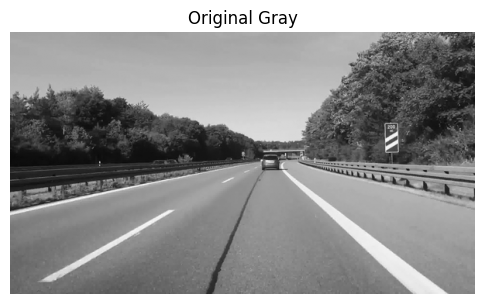

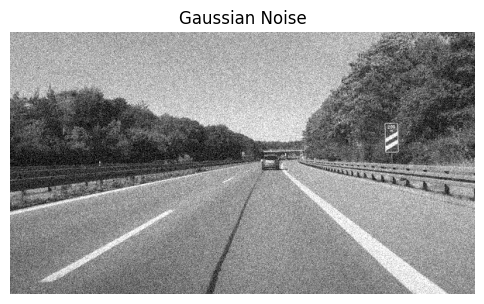

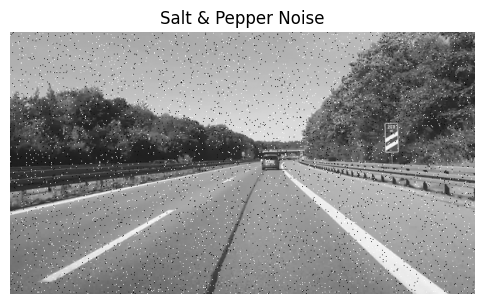

PSNR Gaussian Noise: 22.14758798990573
PSNR Salt & Pepper Noise: 20.541626371693617


In [7]:
# نمایش نویز اضافه شده
imshow(img_gray, "Original Gray")
imshow(gauss_noisy, "Gaussian Noise")
imshow(sp_noisy, "Salt & Pepper Noise")

# محاسبه PSNR
psnr_gauss = psnr(img_gray, gauss_noisy)
psnr_sp = psnr(img_gray, sp_noisy)
print("PSNR Gaussian Noise:", psnr_gauss)
print("PSNR Salt & Pepper Noise:", psnr_sp)


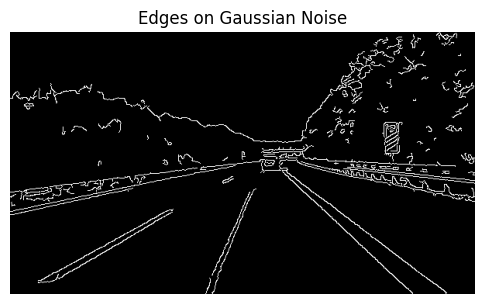

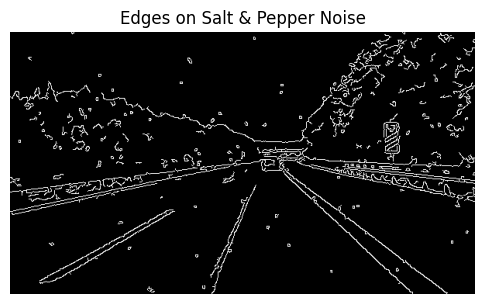

In [8]:
# لبه‌ها با Canny
edges_gauss = auto_canny(gauss_noisy)
edges_sp = auto_canny(sp_noisy)

imshow(edges_gauss, "Edges on Gaussian Noise")
imshow(edges_sp, "Edges on Salt & Pepper Noise")


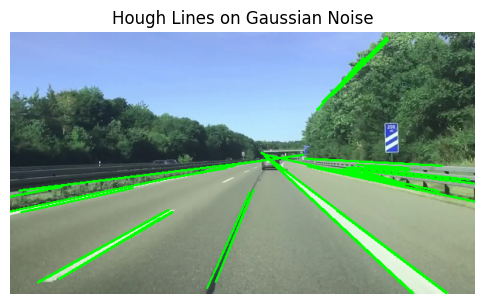

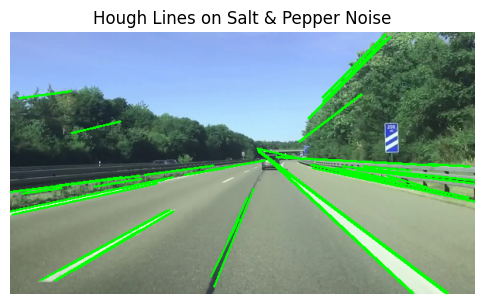

Coverage Gaussian: 0.5054362238133121
Coverage Salt & Pepper: 0.45629275708545985


In [9]:
# خطوط Hough و coverage
lines_gauss = detect_lines_houghp(edges_gauss)
lines_sp = detect_lines_houghp(edges_sp)

def draw_lines(img, lines, color=(0,255,0), thickness=2):
    img_copy = img.copy()
    if lines is not None:
        for x1,y1,x2,y2 in lines.reshape(-1,4):
            cv2.line(img_copy, (x1,y1), (x2,y2), color, thickness)
    return img_copy

img_gauss_lines = draw_lines(img_bgr, lines_gauss)
img_sp_lines = draw_lines(img_bgr, lines_sp)

imshow(img_gauss_lines, "Hough Lines on Gaussian Noise")
imshow(img_sp_lines, "Hough Lines on Salt & Pepper Noise")

coverage_gauss = line_coverage(edges_gauss, lines_gauss)
coverage_sp = line_coverage(edges_sp, lines_sp)
print("Coverage Gaussian:", coverage_gauss)
print("Coverage Salt & Pepper:", coverage_sp)


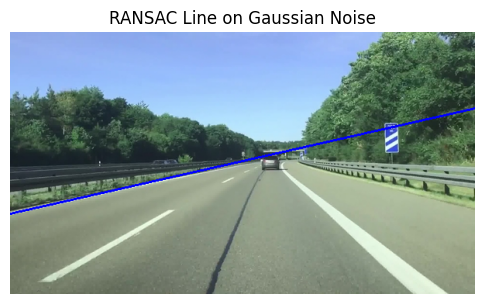

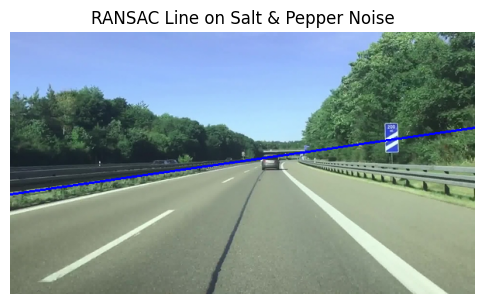

In [10]:
# RANSAC خطوط غالب
model_gauss, inliers_gauss = ransac_line_fit(edges_gauss)
model_sp, inliers_sp = ransac_line_fit(edges_sp)

def draw_ransac_line(img, model, color=(255,0,0), thickness=2):
    img_copy = img.copy()
    if model is None:
        return img_copy
    A,B,C = model
    h, w = img_copy.shape[:2]
    if B != 0:
        y0 = int((-C - A*0)/B)
        y1 = int((-C - A*w)/B)
        cv2.line(img_copy, (0, y0), (w, y1), color, thickness)
    else:
        x = int(-C/A)
        cv2.line(img_copy, (x, 0), (x, h), color, thickness)
    return img_copy

img_gauss_ransac = draw_ransac_line(img_bgr, model_gauss)
img_sp_ransac = draw_ransac_line(img_bgr, model_sp)

imshow(img_gauss_ransac, "RANSAC Line on Gaussian Noise")
imshow(img_sp_ransac, "RANSAC Line on Salt & Pepper Noise")
